#### K562 model

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


def describe_offset_label(val):
    try:
        offset = int(val.replace("offset_", ""))
    except ValueError:
        return val  
    if offset < 0:
        return f"{-offset}"
    elif offset > 0:
        return f"{-offset}"
    else:
        return f"{offset}"
    
def create_heatmap(df, title, output_file):
    plt.figure(figsize=(12, 10), dpi=300)
    sns.set(style='white', font_scale=2)
    pearson_corr = df.corr("pearson")
    r_squared_matrix = pearson_corr**2
    mask = np.triu(np.ones_like(r_squared_matrix, dtype=bool))
    # Remove rows and columns that are fully masked
    unmasked_rows = ~np.all(mask, axis=1)
    unmasked_cols = ~np.all(mask, axis=0)
    trimmed_matrix = r_squared_matrix.loc[unmasked_rows, unmasked_cols]
    trimmed_mask = mask[unmasked_rows, :][:, unmasked_cols]

    print(trimmed_matrix.index)
    print(trimmed_matrix.columns)
    
    trimmed_matrix.index = [describe_offset_label(v) for v in trimmed_matrix.index]
    trimmed_matrix.columns = [describe_offset_label(v) for v in trimmed_matrix.columns]

    colors = ["#053061", "#2166ac", "#4393c3", "#92c5de", "#d1e5f0", 
              "#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"]
    cmap = LinearSegmentedColormap.from_list("custom", colors, N=100)
    
    ax = sns.heatmap(
        trimmed_matrix, 
        annot=True, 
        mask=trimmed_mask, 
        cmap=cmap, 
        vmin=0, 
        vmax=1,
        square=True, 
        linewidths=0.5, 
        # cbar_kws={"label": "Pearson R²\n(Variance Explained)", "shrink": 0.8},
        annot_kws={"size": 14, "weight": "bold"},
        fmt='.2f'  
    )
    
    ax.figure.axes[-1].yaxis.label.set_size(14)  
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_file, format='svg')
    plt.close()


In [2]:
file_path =  "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai.csv.gz"
data = pd.read_csv(file_path, compression='gzip')

for col in data.columns:
    if data[col].dtype == 'object': 
        data[col] = data[col].str.extract(r'\[([-\d.]+)\]').astype(float)

def extract_offset_number(col_name):
    if col_name.startswith("offset_"):
        return int(col_name.replace("offset_", ""))
    return float('inf')  # Non-offset columns go to the end

sorted_cols = sorted(data.columns, key=extract_offset_number, reverse=True)
data = data[sorted_cols]

create_heatmap(data, f"OpenTarget variants: (n={len(data)})", "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai_heatmap.svg")

Index(['offset_80', 'offset_60', 'offset_40', 'offset_20', 'offset_0',
       'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80', 'offset_-90'],
      dtype='object')
Index(['offset_90', 'offset_80', 'offset_60', 'offset_40', 'offset_20',
       'offset_0', 'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80'],
      dtype='object')


### Calculate all by all difference in variant effects

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

offset_cols = ['offset_90', 'offset_80', 'offset_60', 'offset_40', 'offset_20',
               'offset_0', 'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80', "offset_-90"]

diff_df = pd.DataFrame()
for col in offset_cols:
    diff_df[col] = data[col] - data['offset_0']

diff_df.columns = [describe_offset_label(v) for v in diff_df.columns]


In [4]:
diff_df.size

1136883

/tmp/ipykernel_1188503/2859607302.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


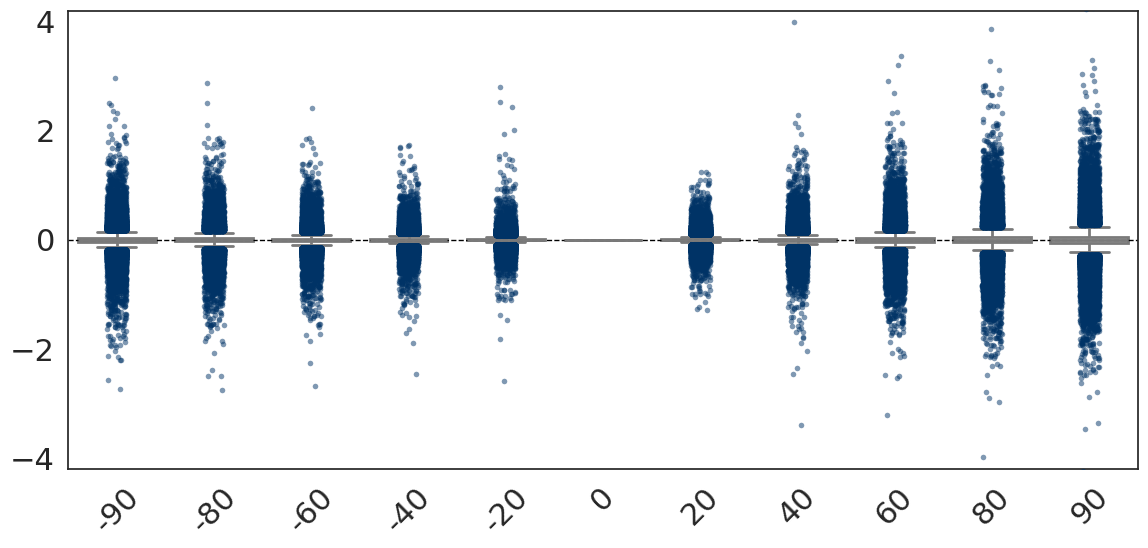

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import rcParams

# Set style and SVG font options
sns.set(style='white', font_scale=2)
rcParams['svg.fonttype'] = 'none'  # Keep SVG text editable

# Melt dataframe
diff_melted = diff_df.melt(var_name='Offset', value_name='Difference in SNP Effect (var shifted - var centre)')

# Compute IQR-based thresholds per Offset
grouped = diff_melted.groupby('Offset')
q1 = grouped['Difference in SNP Effect (var shifted - var centre)'].quantile(0.25)
q3 = grouped['Difference in SNP Effect (var shifted - var centre)'].quantile(0.75)
iqr = q3 - q1

upper_thresh = q3 + 1.5 * iqr
lower_thresh = q1 - 1.5 * iqr

# Function to detect outliers
def is_outlier(row):
    offset = row['Offset']
    val = row['Difference in SNP Effect (var shifted - var centre)']
    return val > upper_thresh.loc[offset] or val < lower_thresh.loc[offset]

# Filter only outlier points
outliers = diff_melted[diff_melted.apply(is_outlier, axis=1)].copy()
outliers['Shifted Value'] = outliers['Difference in SNP Effect (var shifted - var centre)']

# Slightly boost outlier y-values to sit just above IQR box
for idx, row in outliers.iterrows():
    offset = row['Offset']
    val = row['Shifted Value']
    shift = 0.05 
    if val > q3.loc[offset]:
        # print(shift)
        outliers.at[idx, 'Shifted Value'] = val + shift
    elif val < q1.loc[offset]:
        outliers.at[idx, 'Shifted Value'] = val - shift


# Initialize figure
fig, ax = plt.subplots(figsize=(12, 6))

# Define custom grey palette
grey_palette = ['#cccccc'] * diff_melted['Offset'].nunique()

# Plot boxplot without fliers
sns.boxplot(
    x='Offset',
    y='Difference in SNP Effect (var shifted - var centre)',
    data=diff_melted,
    showfliers=False,
    linewidth=2,
    palette=grey_palette,
    ax=ax
)

# Plot adjusted outliers as jittered stripplot
strip = sns.stripplot(
    x='Offset',
    y='Shifted Value',
    data=outliers,
    color='#003366',   # Deep navy blue
    alpha=0.5,
    jitter=True,
    size=4,
    ax=ax
)

# Rasterize only the outlier dots
for coll in strip.collections:
    coll.set_rasterized(True)

# Add baseline and style
ax.set_ylim(-4.2, 4.2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()

# Save to SVG
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/diff_snp_boxplot.svg",
    format='svg',
    dpi=300
)

plt.show()


### Filter out the dfs

In [6]:
data["offset_0"]

0        -0.058030
1         0.049245
2         0.011797
3         0.087930
4         0.922576
            ...   
103348    0.090925
103349   -0.030026
103350    0.013650
103351    0.149030
103352   -0.043858
Name: offset_0, Length: 103353, dtype: float64

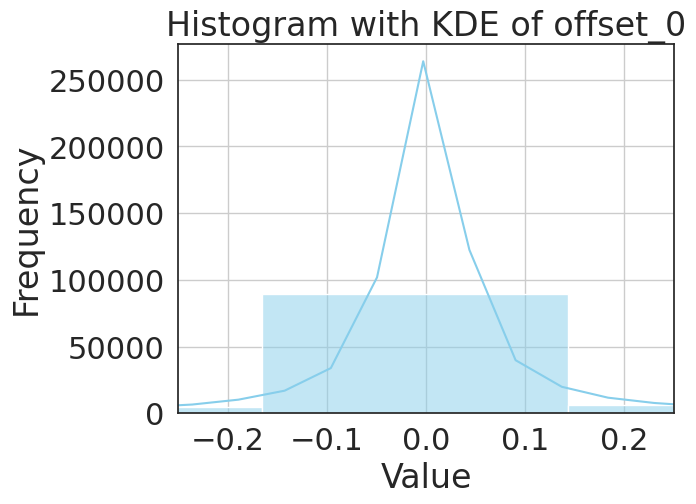

In [7]:
sns.histplot(data["offset_0"], bins=30, kde=True, color='skyblue')
plt.title("Histogram with KDE of offset_0")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.xlim(-0.25, 0.25) 
plt.grid(True)
plt.show()


In [8]:
offset_cols = [col for col in data.columns if col.startswith("offset_")]
mask = (data[offset_cols] < -0.15) | (data[offset_cols] > 0.15)
filtered_data = data[mask.any(axis=1)]


In [9]:
filtered_data
sorted_cols = sorted(filtered_data.columns, key=extract_offset_number, reverse=True)
filtered_data = filtered_data[sorted_cols]

In [10]:
len(filtered_data)

43779

In [11]:
filtered_data

,offset_90,offset_80,offset_60,offset_40,offset_20,offset_0,offset_-20,offset_-40,offset_-60,offset_-80,offset_-90
1,-0.107643,-0.038762,0.022820,0.044842,0.032295,0.049245,0.047405,-0.001595,-0.175751,-0.151906,-0.232132
4,0.757836,0.404994,0.844249,0.946532,0.893546,0.922576,0.916269,1.027890,0.926143,0.770286,0.635050
8,-0.043826,-0.050718,-0.069052,-0.030846,-0.022158,-0.017442,-0.019541,-0.011334,-0.012702,-0.282414,-0.090733
13,-0.077398,-0.080535,-0.072114,-0.067333,-0.156083,-0.154471,-0.194403,-0.093101,-0.143727,-0.202505,-0.207383
14,0.023516,0.026521,0.002192,0.012525,0.033544,0.017080,-0.028378,-0.045723,-0.076650,-0.167388,-0.055283
...,...,...,...,...,...,...,...,...,...,...,...
103345,0.074434,0.044622,0.094641,0.122480,0.085676,0.089836,0.140942,0.194206,0.167167,0.376939,0.477039
103347,0.681066,0.903347,1.427566,1.188394,1.784255,1.945329,2.141184,2.116073,2.256315,2.583283,1.342930
103348,0.061652,0.166417,0.041727,0.049957,0.064640,0.090925,0.128922,0.137385,0.172466,0.181231,0.163812
103351,-0.001304,0.026618,0.022130,0.046370,0.107420,0.149030,0.264447,0.240210,0.083498,0.112178,0.148800


In [12]:
create_heatmap(filtered_data, f"OpenTarget variants: (n={len(filtered_data)})", "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai_filtered_0.15.svg")

Index(['offset_80', 'offset_60', 'offset_40', 'offset_20', 'offset_0',
       'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80', 'offset_-90'],
      dtype='object')
Index(['offset_90', 'offset_80', 'offset_60', 'offset_40', 'offset_20',
       'offset_0', 'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80'],
      dtype='object')


### Filter with a stricter threshold

In [13]:
offset_cols = [col for col in data.columns if col.startswith("offset_")]
mask = (data[offset_cols] < -0.25) | (data[offset_cols] > 0.25)
filtered_data_2 = data[mask.any(axis=1)]
sorted_cols = sorted(filtered_data_2.columns, key=extract_offset_number, reverse=True)
filtered_data_2 = filtered_data_2[sorted_cols]
create_heatmap(filtered_data_2, f"OpenTarget variants: (n={len(filtered_data_2)})", "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai_filtered_0.25.svg")

Index(['offset_80', 'offset_60', 'offset_40', 'offset_20', 'offset_0',
       'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80', 'offset_-90'],
      dtype='object')
Index(['offset_90', 'offset_80', 'offset_60', 'offset_40', 'offset_20',
       'offset_0', 'offset_-20', 'offset_-40', 'offset_-60', 'offset_-80'],
      dtype='object')
